In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate
import math
import numpy as np
import pingouin as pg
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import roc_curve, roc_auc_score

## Load Data Set

In [2]:
#from github
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "48-hour-exam/group_3_faa_data_subset/group_3_faa_data_subset/faa_data_subset.xlsx"

github_url = f"https://raw.githubusercontent.com/{username}/{repository}/master/{directory}"
df = pd.read_excel(github_url)


## Basic Data Inspection and Cleaning

In [3]:
# Display the shape of the dataframe
df.shape

(28298, 25)

In [4]:
# Display the info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28298 entries, 0 to 28297
Data columns (total 25 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Airport: Code                               28298 non-null  object        
 1   Airport: Name                               28298 non-null  object        
 2   Origin State                                28298 non-null  object        
 3   Origin State Code                           28298 non-null  object        
 4   Country                                     28298 non-null  object        
 5   Aircraft: Type                              27467 non-null  object        
 6   Aircraft: Number of engines                 25918 non-null  float64       
 7   Collision Date and Time                     28298 non-null  datetime64[ns]
 8   When: Time of day                           27655 non-null  object        
 9   When: 

In [5]:
# Display the first few rows of the dataframe
df.head()

,Airport: Code,Airport: Name,Origin State,Origin State Code,Country,Aircraft: Type,Aircraft: Number of engines,Collision Date and Time,When: Time of day,When: Phase of flight,...,Days,Feet above ground,Miles from airport,Wildlife: Animal Category,Wildlife: Species Order,Wildlife: Species Group,Wildlife: Species,Wildlife: Species ID,Number of Strikes,Record ID
0,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,NaN,NaN,2012-09-20 19:30:00,NaN,Take-off run,...,NaN,0.0,NaN,Terrestrial Mammals,Canids,"Wolves, Dogs, Foxes, Coyote",Domestic dog,1F12,1,17459
1,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,Airplane,1.0,2013-04-23 17:09:00,NaN,Take-off run,...,NaN,NaN,NaN,Birds,"Pelicans, Herons, Egrets, Bitterns, Ibises","Herons, Egrets, Bitterns","Herons, egrets, bitterns",I1,1,17114
2,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-04-23 09:22:00,Day,Take-off run,...,30.000,0.0,0.0,Birds,"Caracaras, Falcons","Caracaras, Falcons",American kestrel,K5114,1,259361
3,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2014-04-13 22:00:00,Night,Approach,...,0.625,NaN,NaN,Birds,Pigeons and Doves,Doves,Mourning dove,O2205,1,345167
4,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-03-31 18:15:00,Day,Approach,...,0.500,NaN,0.0,Birds,"Hawks, Kites, Eagles, Ospreys, Vultures","Kites, Hawks, Eagles",Red-tailed hawk,K3302,1,262782


In [6]:
# Checking the categorical columns
df.select_dtypes(include=object).head()

,Airport: Code,Airport: Name,Origin State,Origin State Code,Country,Aircraft: Type,When: Time of day,When: Phase of flight,Effect: Amount of damage (detailed),Effect: Impact to flight,Effect: Indicated Damage,Wildlife: Animal Category,Wildlife: Species Order,Wildlife: Species Group,Wildlife: Species,Wildlife: Species ID
0,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,NaN,NaN,Take-off run,NaN,NaN,No damage,Terrestrial Mammals,Canids,"Wolves, Dogs, Foxes, Coyote",Domestic dog,1F12
1,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,Airplane,NaN,Take-off run,NaN,NaN,No damage,Birds,"Pelicans, Herons, Egrets, Bitterns, Ibises","Herons, Egrets, Bitterns","Herons, egrets, bitterns",I1
2,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,Day,Take-off run,Medium,Aborted Take-off,Caused damage,Birds,"Caracaras, Falcons","Caracaras, Falcons",American kestrel,K5114
3,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,Night,Approach,NaN,NaN,No damage,Birds,Pigeons and Doves,Doves,Mourning dove,O2205
4,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,Day,Approach,Medium,NaN,Caused damage,Birds,"Hawks, Kites, Eagles, Ospreys, Vultures","Kites, Hawks, Eagles",Red-tailed hawk,K3302


In [7]:
# Checking the numerical columns
df.select_dtypes(include=np.number).head()

,Aircraft: Number of engines,Cost: Aircraft time out of service (hours),Cost: Total $,Days,Feet above ground,Miles from airport,Number of Strikes,Record ID
0,NaN,NaN,0,NaN,0.0,NaN,1,17459
1,1.0,NaN,0,NaN,NaN,NaN,1,17114
2,2.0,720.0,171132,30.000,0.0,0.0,1,259361
3,2.0,15.0,600,0.625,NaN,NaN,1,345167
4,2.0,12.0,188245,0.500,NaN,0.0,1,262782


In [8]:
# Display the summary statistics of the dataframe
df.describe().round(0)

,Aircraft: Number of engines,Collision Date and Time,Cost: Aircraft time out of service (hours),Cost: Total $,Days,Feet above ground,Miles from airport,Number of Strikes,Record ID
count,25918.0,28298,2929.0,28298.0,2929.0,24872.0,19807.0,28298.0,28298.0
mean,2.0,2009-08-02 02:55:58.905929728,85.0,11385.0,4.0,339.0,0.0,1.0,271474.0
min,1.0,2000-01-02 10:27:00,0.0,0.0,0.0,0.0,0.0,1.0,1164.0
25%,2.0,2006-07-21 11:55:00,1.0,0.0,0.0,0.0,0.0,1.0,235364.0
50%,2.0,2010-07-17 07:42:00,2.0,0.0,0.0,0.0,0.0,1.0,301697.0
75%,2.0,2013-01-27 07:36:15,24.0,0.0,1.0,100.0,0.0,1.0,330425.0
max,4.0,2015-05-31 21:47:00,21000.0,41071585.0,875.0,20000.0,100.0,1.0,360842.0
std,0.0,NaN,509.0,312536.0,21.0,1065.0,3.0,0.0,81859.0


In [9]:
# display missing values

missing_values = df.isnull().sum()
missing_values_percentage = (missing_values / len(df)) * 100
missing_values_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_values_percentage})
missing_values_df = missing_values_df[missing_values_df['Missing Values'] > 0]
missing_values_df = missing_values_df.sort_values(by='Missing Values', ascending=False)
print(tabulate.tabulate(missing_values_df, headers='keys', tablefmt='psql'))


+--------------------------------------------+------------------+--------------+
|                                            |   Missing Values |   Percentage |
|--------------------------------------------+------------------+--------------|
| Cost: Aircraft time out of service (hours) |            25369 |     89.6494  |
| Days                                       |            25369 |     89.6494  |
| Effect: Impact to flight                   |            25265 |     89.2819  |
| Effect: Amount of damage (detailed)        |            25187 |     89.0063  |
| Miles from airport                         |             8491 |     30.0057  |
| Feet above ground                          |             3426 |     12.1069  |
| Aircraft: Number of engines                |             2380 |      8.41049 |
| Aircraft: Type                             |              831 |      2.9366  |
| When: Time of day                          |              643 |      2.27225 |
| When: Phase of flight     

In [10]:
df.columns = (
    df.columns
      .str.replace('$', '', regex=False)
      .str.strip()
      .str.lower()
      .str.replace(':', '', regex=False)  
      .str.replace('(', '', regex=False)
      .str.replace(')', '', regex=False)
      .str.replace(' ', '_', regex=False)
)

# Print the cleaned column names
print(df.columns)


Index(['airport_code', 'airport_name', 'origin_state', 'origin_state_code',
       'country', 'aircraft_type', 'aircraft_number_of_engines',
       'collision_date_and_time', 'when_time_of_day', 'when_phase_of_flight',
       'effect_amount_of_damage_detailed', 'effect_impact_to_flight',
       'effect_indicated_damage', 'cost_aircraft_time_out_of_service_hours',
       'cost_total', 'days', 'feet_above_ground', 'miles_from_airport',
       'wildlife_animal_category', 'wildlife_species_order',
       'wildlife_species_group', 'wildlife_species', 'wildlife_species_id',
       'number_of_strikes', 'record_id'],
      dtype='object')


In [11]:
#Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [12]:
# Create month column from the date column
df["month"] = df["collision_date_and_time"].dt.month

In [13]:
num_cols = [
    "aircraft_number_of_engines",
    "feet_above_ground",
    "miles_from_airport"
]

df[num_cols].describe().round(2)

,aircraft_number_of_engines,feet_above_ground,miles_from_airport
count,25918.00,24872.00,19807.00
mean,2.00,338.85,0.48
std,0.37,1064.71,2.57
min,1.00,0.00,0.00
25%,2.00,0.00,0.00
50%,2.00,0.00,0.00
75%,2.00,100.00,0.00
max,4.00,20000.00,100.00


## Basic Plots

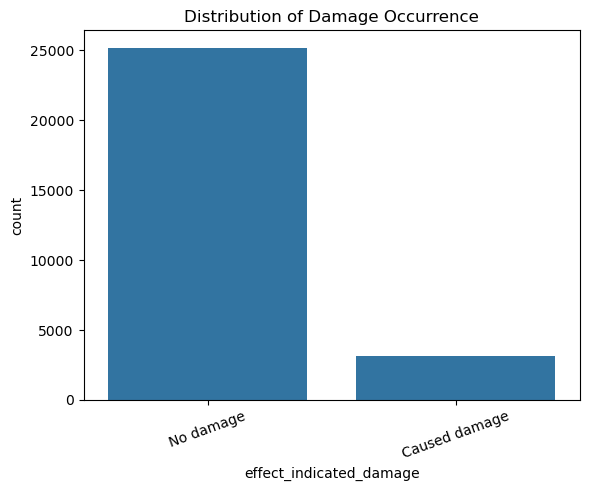

In [14]:
sns.countplot(data=df, x="effect_indicated_damage")
plt.title("Distribution of Damage Occurrence")
plt.xticks(rotation=20)
plt.show()

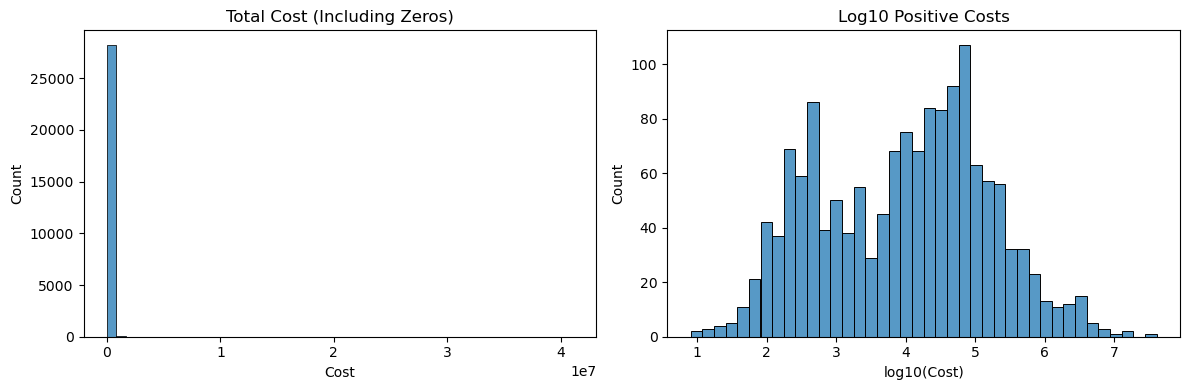

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: All costs (including zeros)
sns.histplot(df["cost_total"], bins=50, ax=axes[0])
axes[0].set_title("Total Cost (Including Zeros)")
axes[0].set_xlabel("Cost")

# Right: Log-transformed positive costs
log_positive_costs = np.log10(df.loc[df["cost_total"] > 0, "cost_total"])

sns.histplot(log_positive_costs, bins=40, ax=axes[1])
axes[1].set_title("Log10 Positive Costs")
axes[1].set_xlabel("log10(Cost)")

plt.tight_layout()
plt.show()

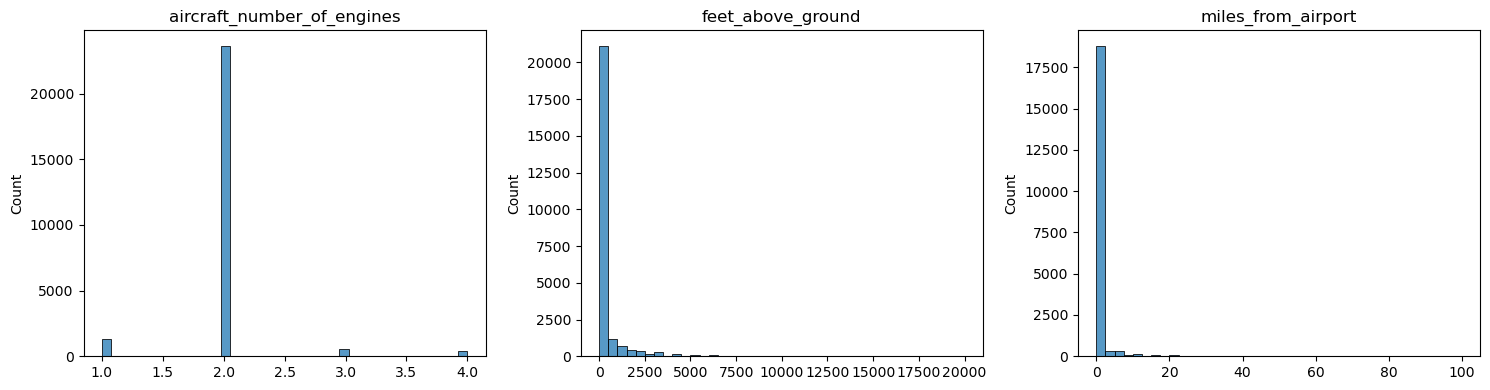

In [16]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=40, ax=ax)
    ax.set_title(f"{col}")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [17]:
# Apply Log-Transformation to Altitude
df['Log_Altitude'] = np.log1p(df['feet_above_ground'])

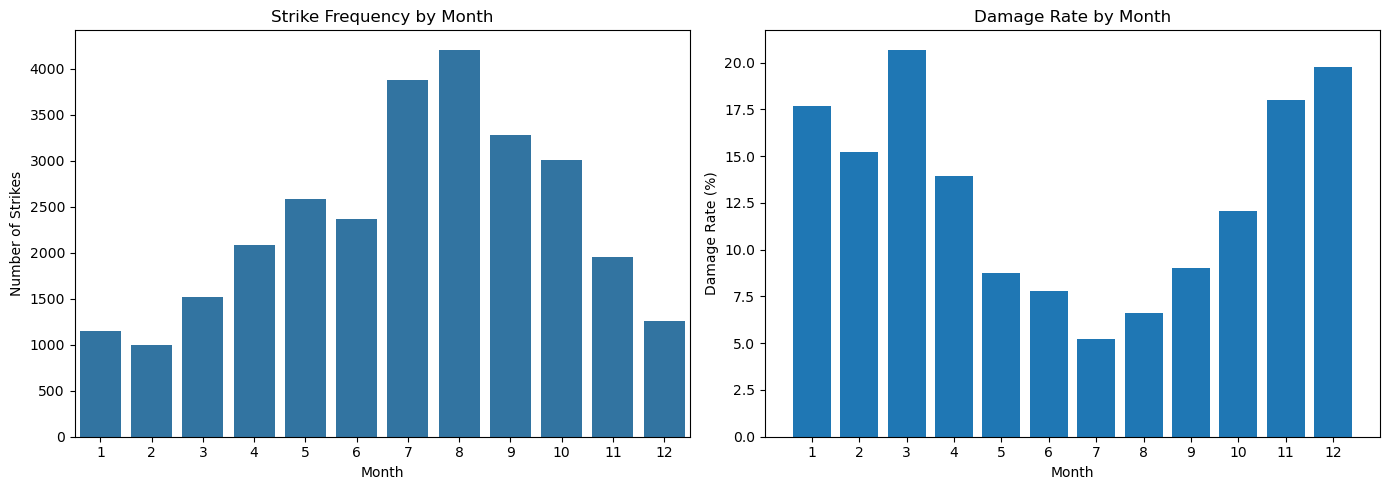

In [18]:
# Damage flag
tmp = df.copy()
tmp["damage_flag"] = (tmp["effect_indicated_damage"] == "Caused damage").astype(int)

# Damage rate by month
damage_by_month = (
    tmp.groupby("month")["damage_flag"]
       .mean()
       .reindex(range(1, 13)) * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frequency
sns.countplot(data=df, x="month", order=range(1, 13), ax=axes[0])
axes[0].set_title("Strike Frequency by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Strikes")
axes[0].set_xticks(range(0, 12))
axes[0].set_xticklabels(range(1, 13))

# Damage rate
axes[1].bar(damage_by_month.index, damage_by_month.values)
axes[1].set_title("Damage Rate by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Damage Rate (%)")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

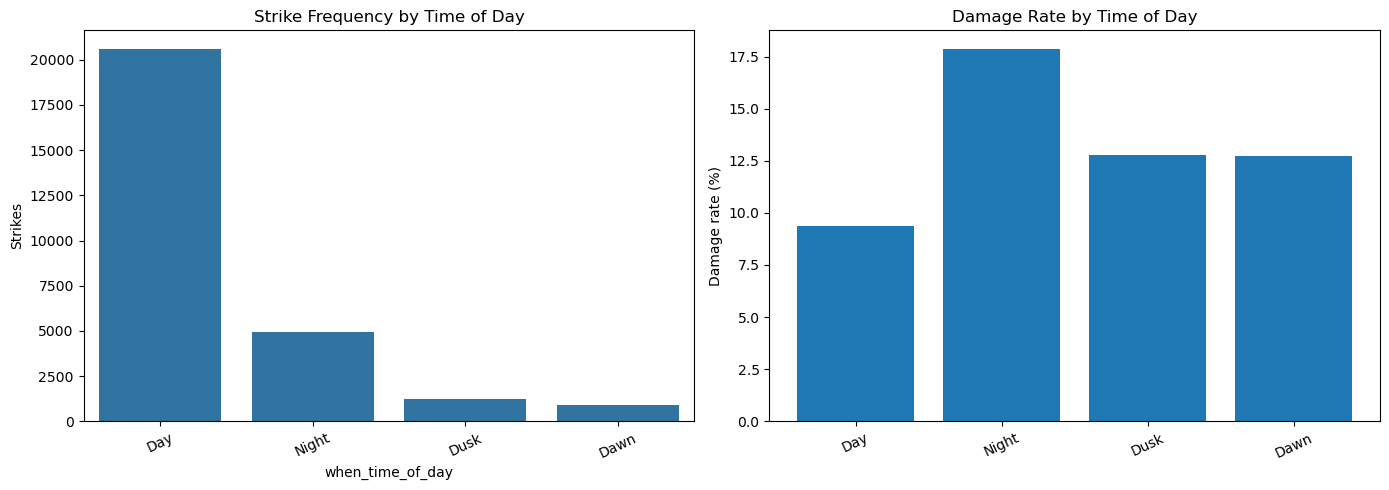

In [19]:
# Order by frequency
time_order = df["when_time_of_day"].dropna().value_counts().index

# Damage flag
tmp = df.copy()
tmp["damage_flag"] = (tmp["effect_indicated_damage"] == "Caused damage").astype(int)

damage_by_time = (
    tmp.groupby("when_time_of_day")["damage_flag"]
       .mean()
       .loc[time_order] * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frequency
sns.countplot(data=df, x="when_time_of_day", order=time_order, ax=axes[0])
axes[0].set_title("Strike Frequency by Time of Day")
axes[0].set_ylabel("Strikes")
axes[0].tick_params(axis="x", rotation=25)

# Damage rate
axes[1].bar(damage_by_time.index.astype(str), damage_by_time.values)
axes[1].set_title("Damage Rate by Time of Day")
axes[1].set_ylabel("Damage rate (%)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

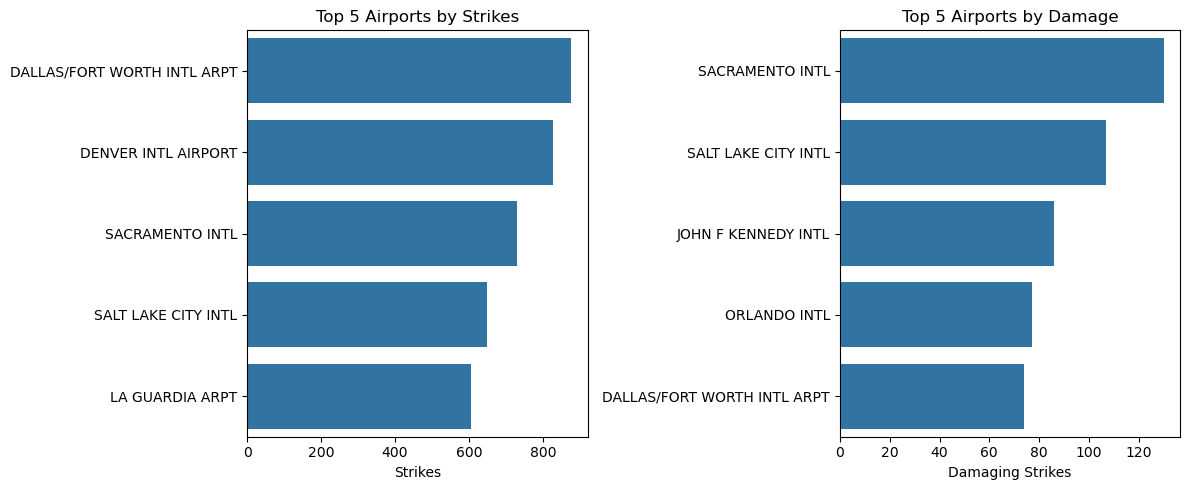

In [20]:
# Damage flag
tmp = df.copy()
tmp["damage_flag"] = (tmp["effect_indicated_damage"] == "Caused damage").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Top airports by strikes
top_strikes = df["airport_name"].fillna("Unknown").value_counts().head(5)
sns.barplot(x=top_strikes.values, y=top_strikes.index, ax=axes[0])
axes[0].set_title("Top 5 Airports by Strikes")
axes[0].set_xlabel("Strikes")
axes[0].set_ylabel("")

# Top airports by damage
top_damage = (
    tmp.groupby("airport_name")["damage_flag"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
sns.barplot(x=top_damage.values, y=top_damage.index, ax=axes[1])
axes[1].set_title("Top 5 Airports by Damage")
axes[1].set_xlabel("Damaging Strikes")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

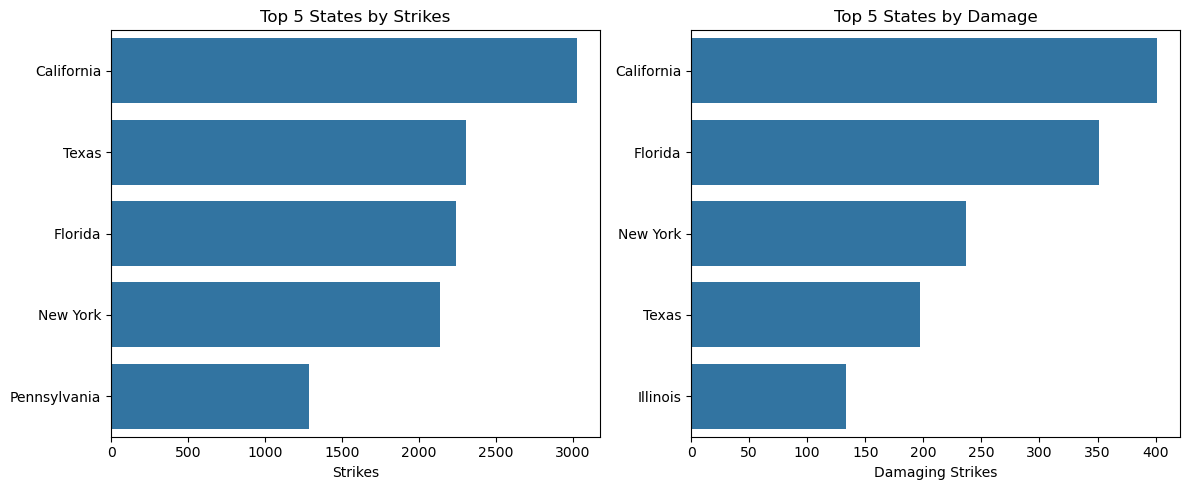

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Top states by strikes
top_strikes = df["origin_state"].fillna("Unknown").value_counts().head(5)
sns.barplot(x=top_strikes.values, y=top_strikes.index, ax=axes[0])
axes[0].set_title("Top 5 States by Strikes")
axes[0].set_xlabel("Strikes")
axes[0].set_ylabel("")

# Top states by damage
top_damage = (
    tmp.groupby("origin_state")["damage_flag"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
sns.barplot(x=top_damage.values, y=top_damage.index, ax=axes[1])
axes[1].set_title("Top 5 States by Damage")
axes[1].set_xlabel("Damaging Strikes")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

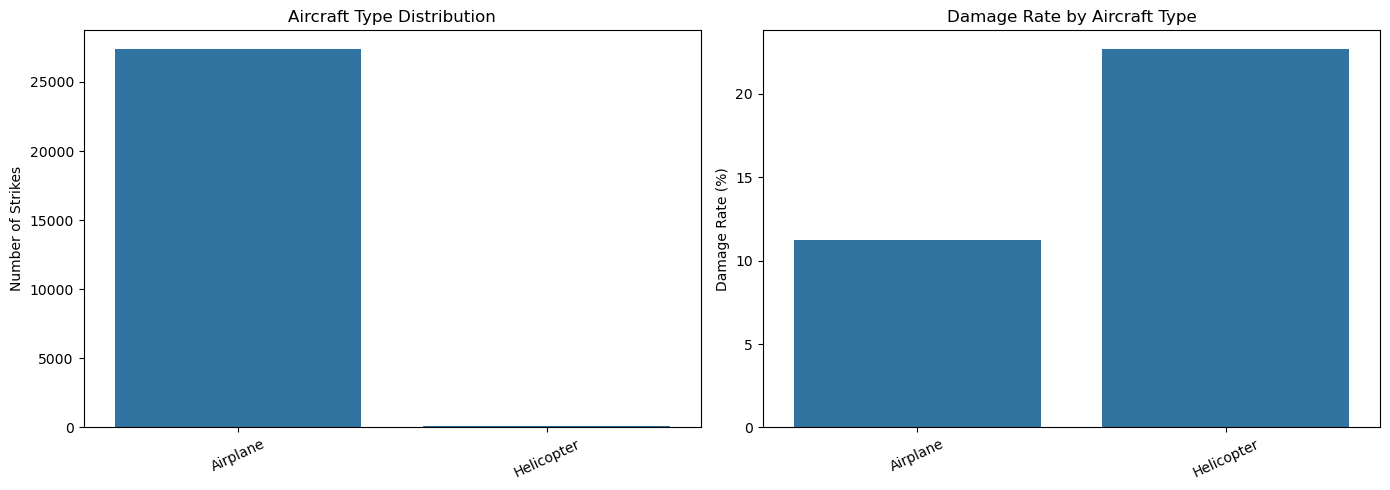

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create damage flag
tmp = df.copy()
tmp["damage_flag"] = (tmp["effect_indicated_damage"] == "Caused damage").astype(int)

# Order by frequency (for consistency)
order = df["aircraft_type"].value_counts().index

# Damage percentage by aircraft type
damage_pct = (
    tmp.groupby("aircraft_type")["damage_flag"]
       .mean()
       .reindex(order) * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Distribution
sns.countplot(data=df, x="aircraft_type", order=order, ax=axes[0])
axes[0].set_title("Aircraft Type Distribution")
axes[0].set_ylabel("Number of Strikes")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)

# Right — Damage %
sns.barplot(x=damage_pct.index, y=damage_pct.values, ax=axes[1])
axes[1].set_title("Damage Rate by Aircraft Type")
axes[1].set_ylabel("Damage Rate (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

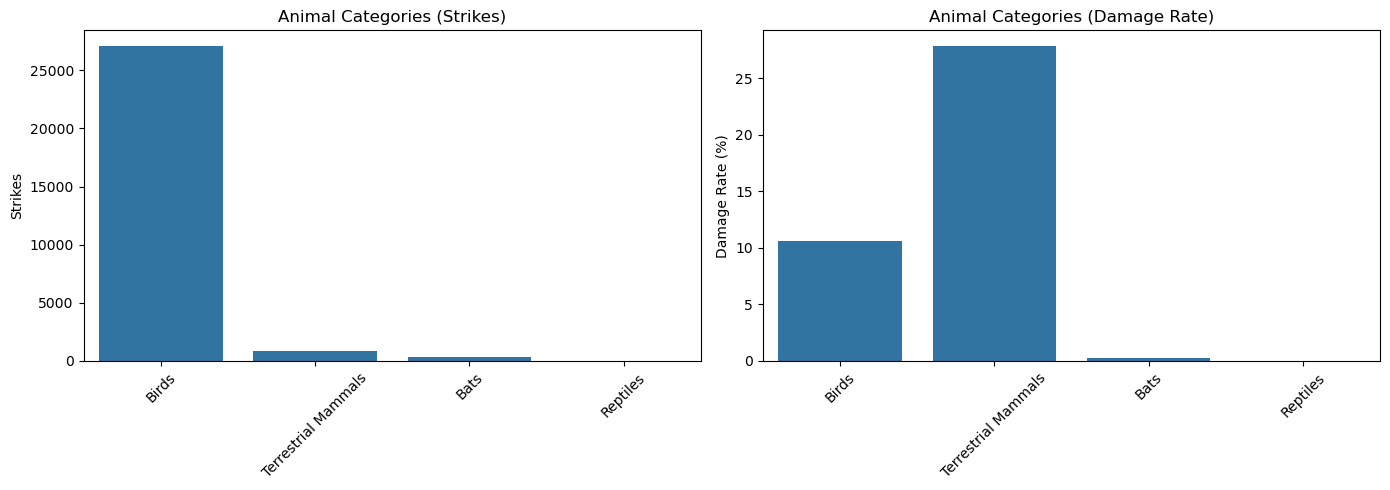

In [23]:
# Create damage flag
tmp = df.copy()
tmp["damage_flag"] = (tmp["effect_indicated_damage"] == "Caused damage").astype(int)

# Order categories by frequency
cat_order = df["wildlife_animal_category"].value_counts().index

# Damage rate within each category (%)
cat_damage_rate = (
    tmp.groupby("wildlife_animal_category")["damage_flag"]
    .mean()
    .reindex(cat_order) * 100
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Frequency
sns.countplot(
    data=df,
    x="wildlife_animal_category",
    order=cat_order,
    ax=axes[0]
)
axes[0].set_title("Animal Categories (Strikes)")
axes[0].set_ylabel("Strikes")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

# Right — Damage rate within category
sns.barplot(
    x=cat_damage_rate.index,
    y=cat_damage_rate.values,
    ax=axes[1]
)
axes[1].set_title("Animal Categories (Damage Rate)")
axes[1].set_ylabel("Damage Rate (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

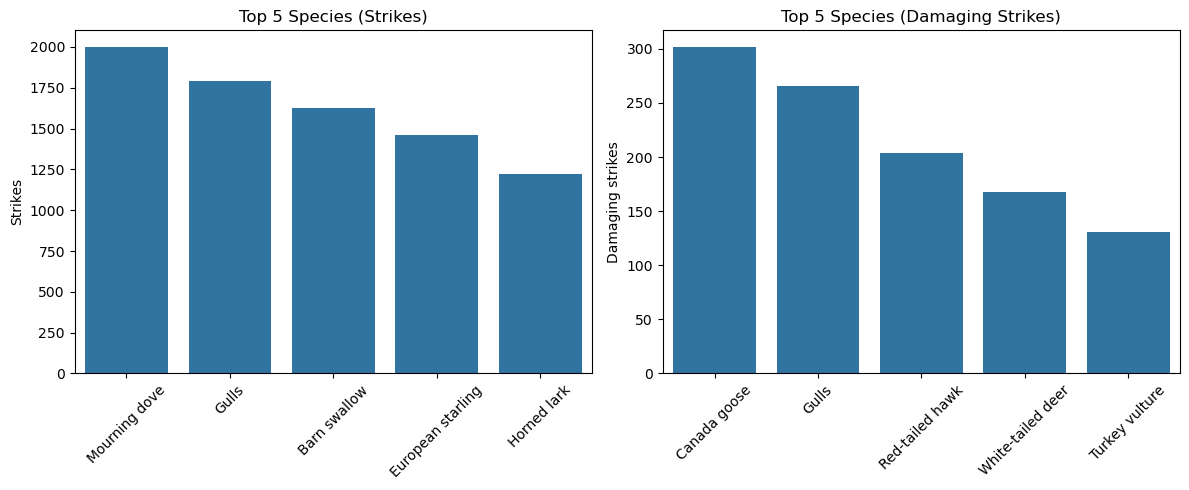

In [24]:
tmp = df.copy()
tmp["damage_flag"] = (tmp["effect_indicated_damage"] == "Caused damage").astype(int)

# Top 5 species by strikes
top_species_strikes = (
    df["wildlife_species"]
    .fillna("Unknown")
    .value_counts()
    .head(5)
)

# Top 5 species by damage
top_species_damage = (
    tmp.groupby("wildlife_species")["damage_flag"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — Strikes
sns.barplot(x=top_species_strikes.index, y=top_species_strikes.values, ax=axes[0])
axes[0].set_title("Top 5 Species (Strikes)")
axes[0].set_ylabel("Strikes")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

# Right — Damage
sns.barplot(x=top_species_damage.index, y=top_species_damage.values, ax=axes[1])
axes[1].set_title("Top 5 Species (Damaging Strikes)")
axes[1].set_ylabel("Damaging strikes")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

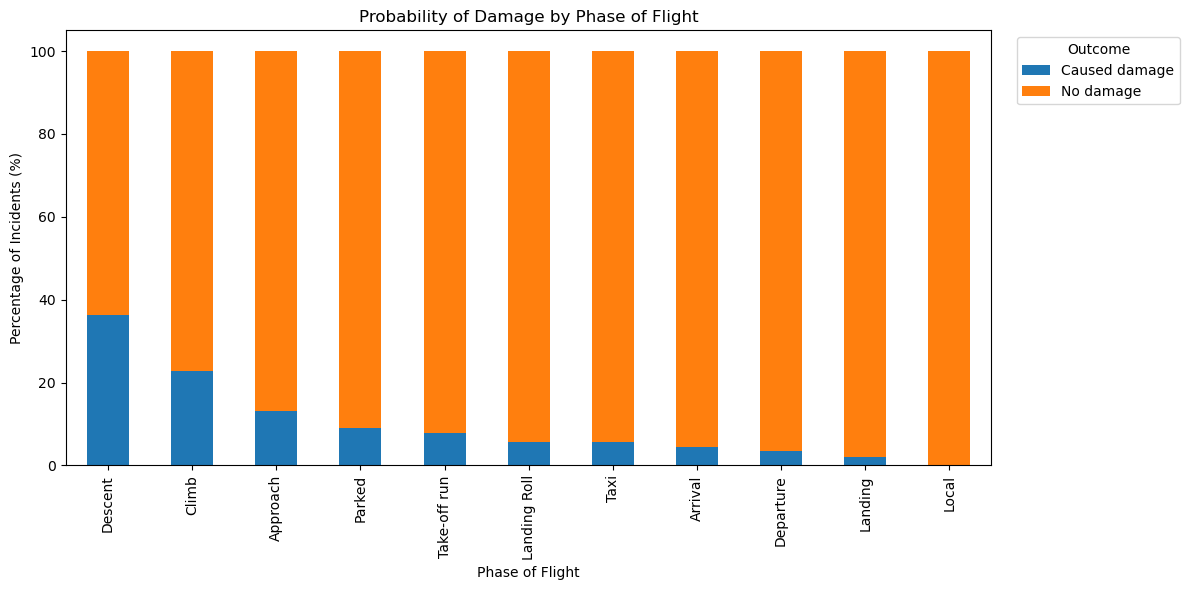

In [25]:
phase_damage = (
    pd.crosstab(
        df["when_phase_of_flight"],
        df["effect_indicated_damage"],
        normalize="index"
    ) * 100
)

# Sort by "Caused damage" if present; otherwise sort by first column
sort_col = "Caused damage" if "Caused damage" in phase_damage.columns else phase_damage.columns[0]
phase_damage = phase_damage.sort_values(by=sort_col, ascending=False)

ax = phase_damage.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set_title("Probability of Damage by Phase of Flight")
ax.set_ylabel("Percentage of Incidents (%)")
ax.set_xlabel("Phase of Flight")
ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

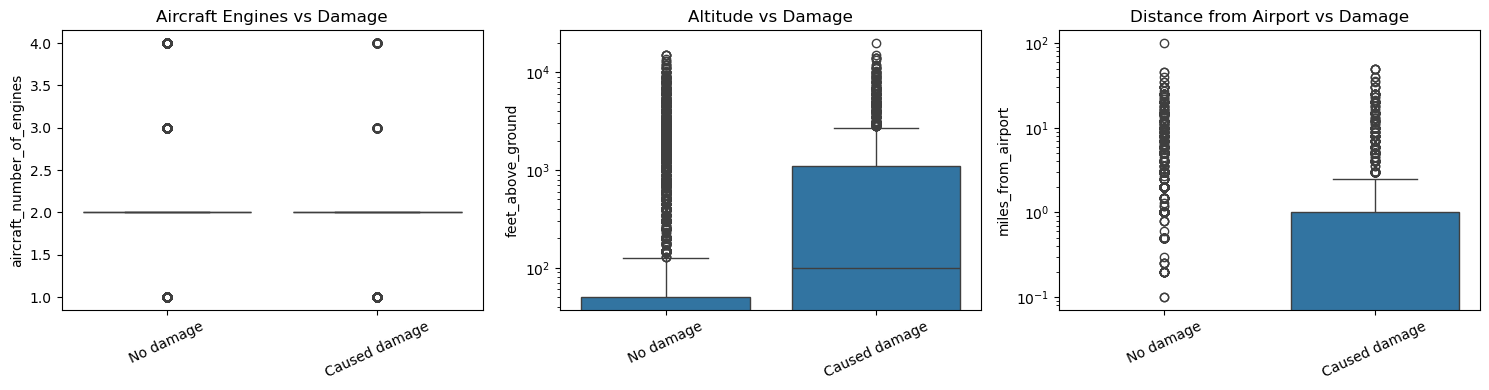

In [26]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))

titles = {
    "aircraft_number_of_engines": "Aircraft Engines vs Damage",
    "feet_above_ground": "Altitude vs Damage",
    "miles_from_airport": "Distance from Airport vs Damage"
}

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="effect_indicated_damage", y=col, ax=ax)
    ax.set_title(titles[col])
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    
    # Log scale for skewed variables
    if col in ["feet_above_ground", "miles_from_airport"]:
        ax.set_yscale("log")

plt.tight_layout()
plt.show()

In [27]:
# Dropping unnecessary columns from the dataset for modeling
cols_to_drop = [
    "airport_code",
    "airport_name",
    "origin_state",
    "origin_state_code",
    "country",
    "wildlife_species_id",
    "record_id",
    "wildlife_species",
   "wildlife_species_group",
    "wildlife_species_order",
    "effect_amount_of_damage_detailed",
    "effect_impact_to_flight",
    "cost_aircraft_time_out_of_service_hours",
    "cost_total",
    "days",
    "number_of_strikes"
]

df1 = df.drop(columns=cols_to_drop)

### Reasons for droppoing columns in df1

Identifiers (no predictive value)

airport_code: unique airport identifier with no explanatory meaning.
airport_name: descriptive airport label redundant with airport_code.
record_id: unique incident identifier with zero analytical relevance.

Geographic Detail (not central to research question & adds high dimensionality)

origin_state: geographic category not directly related to operational/environmental mechanisms of damage.
origin_state_code: coded version of origin_state with no additional explanatory value.
country: near-constant geographic variable offering minimal variation in this dataset.

Overly Granular Wildlife Taxonomy (risk of overfitting & poor interpretability)

wildlife_species: highly detailed species variable creating excessive dummy variables.
wildlife_species_group: intermediate taxonomy level still too granular for stable modeling.
wildlife_species_order: higher taxonomy grouping duplicating information captured by broader categories.
wildlife_species_id: coded species identifier with no independent predictive meaning.

Post-Outcome / Target Leakage Variables (occur after damage)

effect_amount_of_damage_detailed: describes severity after damage occurs, causing leakage.
effect_impact_to_flight: consequence of damage rather than a cause, leading to leakage bias.

Economic Consequence Variables (not relevant to damage probability)

cost_aircraft_time_out_of_service_hours: reflects post-incident operational impact, not damage likelihood.
cost_total: financial outcome variable unrelated to modeling physical damage occurrence.
days: duration of impact after incident, not a causal predictor of damage.

number_of_strikes: removed due to zero variance (all observations equal to 1), providing no explanatory power.

In [28]:
df1


,aircraft_type,aircraft_number_of_engines,collision_date_and_time,when_time_of_day,when_phase_of_flight,effect_indicated_damage,feet_above_ground,miles_from_airport,wildlife_animal_category,month,Log_Altitude
0,NaN,NaN,2012-09-20 19:30:00,NaN,Take-off run,No damage,0.0,NaN,Terrestrial Mammals,9,0.000000
1,Airplane,1.0,2013-04-23 17:09:00,NaN,Take-off run,No damage,NaN,NaN,Birds,4,NaN
2,Airplane,2.0,2009-04-23 09:22:00,Day,Take-off run,Caused damage,0.0,0.0,Birds,4,0.000000
3,Airplane,2.0,2014-04-13 22:00:00,Night,Approach,No damage,NaN,NaN,Birds,4,NaN
4,Airplane,2.0,2009-03-31 18:15:00,Day,Approach,Caused damage,NaN,0.0,Birds,3,NaN
...,...,...,...,...,...,...,...,...,...,...,...
28293,Airplane,4.0,2011-11-16 18:20:00,NaN,Approach,No damage,100.0,NaN,Birds,11,4.615121
28294,Airplane,4.0,2012-11-01 21:20:00,NaN,Approach,No damage,1900.0,NaN,Birds,11,7.550135
28295,Airplane,4.0,2014-05-07 22:00:00,NaN,Take-off run,No damage,NaN,NaN,Birds,5,NaN
28296,Airplane,4.0,2013-10-28 18:30:00,NaN,Approach,No damage,NaN,NaN,Birds,10,NaN


In [29]:
# display missing values on the cleaned dataframe

missing_values = df1.isnull().sum()
missing_values_percentage = (missing_values / len(df1)) * 100
missing_values_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_values_percentage})
missing_values_df = missing_values_df[missing_values_df['Missing Values'] > 0]
missing_values_df = missing_values_df.sort_values(by='Missing Values', ascending=False)
print(tabulate.tabulate(missing_values_df, headers='keys', tablefmt='psql'))


+----------------------------+------------------+--------------+
|                            |   Missing Values |   Percentage |
|----------------------------+------------------+--------------|
| miles_from_airport         |             8491 |     30.0057  |
| feet_above_ground          |             3426 |     12.1069  |
| Log_Altitude               |             3426 |     12.1069  |
| aircraft_number_of_engines |             2380 |      8.41049 |
| aircraft_type              |              831 |      2.9366  |
| when_time_of_day           |              643 |      2.27225 |
| when_phase_of_flight       |              406 |      1.43473 |
+----------------------------+------------------+--------------+


In [30]:
# Create binary target
df1["damage_flag"] = (df1["effect_indicated_damage"] == "Caused damage").astype(int)

# Class balance
df1["damage_flag"].value_counts()
df1["damage_flag"].value_counts(normalize=True)

damage_flag
0    0.890063
1    0.109937
Name: proportion, dtype: float64

### Exploring missingness of miles_from_airport column

In [31]:
df1["miles_missing"] = df1["miles_from_airport"].isna().astype(int)
df1.groupby("miles_missing")["damage_flag"].mean()

miles_missing
0    0.089867
1    0.156754
Name: damage_flag, dtype: float64

In [32]:
ct = pd.crosstab(df1["miles_missing"], df1["damage_flag"])
chi2, p, dof, expected = chi2_contingency(ct)

print("Contingency Table:\n", ct)
print("\nChi-square =", chi2)
print("p-value =", p)

Contingency Table:
 damage_flag        0     1
miles_missing             
0              18027  1780
1               7160  1331

Chi-square = 271.04847758156575
p-value = 6.705014860224835e-61


In [33]:
cont_cols = [
    "Log_Altitude",
    "miles_from_airport",
    "aircraft_number_of_engines"
]

corr_spearman = df1[cont_cols].corr(method="spearman")
corr_spearman

,Log_Altitude,miles_from_airport,aircraft_number_of_engines
Log_Altitude,1.000000,0.609367,-0.037130
miles_from_airport,0.609367,1.000000,-0.017125
aircraft_number_of_engines,-0.037130,-0.017125,1.000000


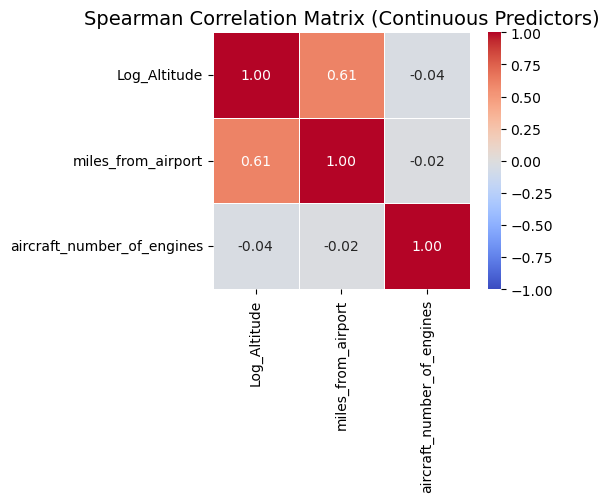

In [34]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_spearman, 
    annot=True,         
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    linewidths=0.5, 
    square=True, 
    fmt=".2f"          
)

plt.title("Spearman Correlation Matrix (Continuous Predictors)", fontsize=14)
plt.tight_layout()
plt.show()

#### The variable miles_from_airport was dropped because it had 30% missing values, and those missing values were strongly associated with damage outcomes, meaning keeping the variable would remove a large, biased portion of the dataset and distort the model.

In [35]:
df_model = df1.drop(columns=["miles_from_airport"])

In [36]:
cat_vars = [
    "when_time_of_day",
    "when_phase_of_flight",
    "aircraft_type",
    "wildlife_animal_category",
    "month"
]

chi_results = []

for var in cat_vars:
    sub = df_model[[var, "damage_flag"]].dropna()
    ct = pd.crosstab(sub[var], sub["damage_flag"])

    # Need at least 2 categories
    if ct.shape[0] < 2:
        continue
    
    chi2, p, dof, expected = chi2_contingency(ct)
    chi_results.append([var, sub.shape[0], chi2, p])

chi_df = pd.DataFrame(chi_results, columns=["Variable", "N Used", "Chi2", "p-value"])
chi_df.sort_values("p-value")

,Variable,N Used,Chi2,p-value
1,when_phase_of_flight,27892,987.637805,8.605182e-206
4,month,28298,701.179624,3.013793e-143
0,when_time_of_day,27655,297.179424,4.057061e-64
3,wildlife_animal_category,28298,291.766560,6.020537e-63
2,aircraft_type,27467,11.549695,6.776038e-04


In [37]:
def univariate_logit(df, x, y="damage_flag"):
    sub = df_model[[x, y]].dropna()
    X = sm.add_constant(sub[x])
    model = sm.Logit(sub[y], X).fit(disp=False)
    
    coef = model.params[x]
    se = model.bse[x]
    p = model.pvalues[x]
    OR = np.exp(coef)
    CI_low, CI_high = np.exp(coef - 1.96*se), np.exp(coef + 1.96*se)
    
    return [x, sub.shape[0], OR, CI_low, CI_high, p]

num_vars = ["Log_Altitude", "aircraft_number_of_engines"]

uni_num_results = []

for var in num_vars:
    try:
        uni_num_results.append(univariate_logit(df_model, var))
    except Exception as e:
        print("Skipped", var, "because:", e)

num_df = pd.DataFrame(
    uni_num_results, 
    columns=["Variable", "N Used", "Odds Ratio", "CI Low", "CI High", "p-value"]
)

num_df.sort_values("p-value")

,Variable,N Used,Odds Ratio,CI Low,CI High,p-value
0,Log_Altitude,24872,1.252235,1.23606,1.268621,4.666784e-252
1,aircraft_number_of_engines,25918,0.553517,0.49336,0.621010,7.062790e-24


In [38]:
for col in ["when_phase_of_flight", "when_time_of_day", "wildlife_animal_category", "aircraft_type", "month"]:
    print("\n", col)
    print(df_model[col].value_counts(dropna=False).head(20))


 when_phase_of_flight
when_phase_of_flight
Approach        9625
Landing Roll    7527
Take-off run    6579
Climb           3402
NaN              406
Descent          250
Landing          239
Taxi             123
Departure         57
Local             45
Arrival           23
Parked            22
Name: count, dtype: int64

 when_time_of_day
when_time_of_day
Day      20602
Night     4926
Dusk      1254
Dawn       873
NaN        643
Name: count, dtype: int64

 wildlife_animal_category
wildlife_animal_category
Birds                  27089
Terrestrial Mammals      844
Bats                     332
Reptiles                  33
Name: count, dtype: int64

 aircraft_type
aircraft_type
Airplane      27370
NaN             831
Helicopter       97
Name: count, dtype: int64

 month
month
8     4209
7     3875
9     3286
10    3007
5     2590
6     2368
4     2084
11    1959
3     1522
12    1256
1     1149
2      993
Name: count, dtype: int64


In [39]:
major_phases = ["Approach", "Landing Roll", "Take-off run", "Climb", "Descent"]
df_model["when_phase_of_flight"] = df_model["when_phase_of_flight"].fillna("Other")

df_model.loc[~df_model["when_phase_of_flight"].isin(major_phases),
             "when_phase_of_flight"] = "Other"


df_model["wildlife_animal_category"] = df_model["wildlife_animal_category"].replace({
    "Bats": "Other Wildlife",
    "Reptiles": "Other Wildlife",
   
})


df_model["aircraft_type"] = df_model["aircraft_type"].fillna("Unknown")
df_model["when_time_of_day"] = df_model["when_time_of_day"].fillna("Unknown")

df_model["season"] = df_model["month"].replace({
    12:"Winter", 1:"Winter", 2:"Winter",
    3:"Spring", 4:"Spring", 5:"Spring",
    6:"Summer", 7:"Summer", 8:"Summer",
    9:"Fall", 10:"Fall", 11:"Fall"
})

In [40]:
for col in ["when_phase_of_flight", "when_time_of_day", "wildlife_animal_category", "aircraft_type", "season"]:
    print("\n", col)
    print(df_model[col].value_counts(dropna=False).head(20))


 when_phase_of_flight
when_phase_of_flight
Approach        9625
Landing Roll    7527
Take-off run    6579
Climb           3402
Other            915
Descent          250
Name: count, dtype: int64

 when_time_of_day
when_time_of_day
Day        20602
Night       4926
Dusk        1254
Dawn         873
Unknown      643
Name: count, dtype: int64

 wildlife_animal_category
wildlife_animal_category
Birds                  27089
Terrestrial Mammals      844
Other Wildlife           365
Name: count, dtype: int64

 aircraft_type
aircraft_type
Airplane      27370
Unknown         831
Helicopter       97
Name: count, dtype: int64

 season
season
Summer    10452
Fall       8252
Spring     6196
Winter     3398
Name: count, dtype: int64


In [41]:
for col in ["when_phase_of_flight", "when_time_of_day", 
            "wildlife_animal_category", "aircraft_type", "season"]:
    print("\n\n====>", col)
    print(df_model.groupby(col)["damage_flag"].agg(['count','sum','mean']))



====> when_phase_of_flight
                      count   sum      mean
when_phase_of_flight                       
Approach               9625  1254  0.130286
Climb                  3402   776  0.228101
Descent                 250    91  0.364000
Landing Roll           7527   435  0.057792
Other                   915    33  0.036066
Take-off run           6579   522  0.079343


====> when_time_of_day
                  count   sum      mean
when_time_of_day                       
Dawn                873   111  0.127148
Day               20602  1927  0.093535
Dusk               1254   160  0.127592
Night              4926   880  0.178644
Unknown             643    33  0.051322


====> wildlife_animal_category
                          count   sum      mean
wildlife_animal_category                       
Birds                     27089  2875  0.106132
Other Wildlife              365     1  0.002740
Terrestrial Mammals         844   235  0.278436


====> aircraft_type
               coun

In [42]:
df_model = df_model[df_model["wildlife_animal_category"] != "Other Wildlife"]

In [43]:
for col in ["when_phase_of_flight", "when_time_of_day", 
            "wildlife_animal_category", "aircraft_type", "season"]:
    print("\n\n====>", col)
    print(df_model.groupby(col)["damage_flag"].agg(['count','sum','mean']))



====> when_phase_of_flight
                      count   sum      mean
when_phase_of_flight                       
Approach               9378  1254  0.133717
Climb                  3373   776  0.230062
Descent                 247    91  0.368421
Landing Roll           7486   435  0.058108
Other                   901    33  0.036626
Take-off run           6548   521  0.079566


====> when_time_of_day
                  count   sum      mean
when_time_of_day                       
Dawn                869   111  0.127733
Day               20535  1927  0.093840
Dusk               1239   160  0.129136
Night              4668   880  0.188518
Unknown             622    32  0.051447


====> wildlife_animal_category
                          count   sum      mean
wildlife_animal_category                       
Birds                     27089  2875  0.106132
Terrestrial Mammals         844   235  0.278436


====> aircraft_type
               count   sum      mean
aircraft_type                 

In [44]:
formula = """
damage_flag ~ 
    Log_Altitude +
    aircraft_number_of_engines +
    C(aircraft_type) +
    C(when_phase_of_flight) +
    C(when_time_of_day) +
    C(wildlife_animal_category) +
    C(season)
"""

glm_model = smf.glm(
    formula=formula,
    data=df_model,
    family=sm.families.Binomial()
).fit()

print(glm_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            damage_flag   No. Observations:                22999
Model:                            GLM   Df Residuals:                    22982
Model Family:                Binomial   Df Model:                           16
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7422.5
Date:                Sat, 28 Feb 2026   Deviance:                       14845.
Time:                        14:50:04   Pearson chi2:                 2.37e+04
No. Iterations:                     6   Pseudo R-squ. (CS):            0.08903
Covariance Type:            nonrobust                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [45]:
# Extract basic values
coef = glm_model.params
stderr = glm_model.bse
pvals = glm_model.pvalues
conf = glm_model.conf_int()
conf.columns = ['ci_lower', 'ci_upper']

# Compute odds ratios + CI
odds = np.exp(coef)
odds_ci_lower = np.exp(conf['ci_lower'])
odds_ci_upper = np.exp(conf['ci_upper'])

# Identify "significant" predictors where CI does NOT cross 1
significant = ~((odds_ci_lower <= 1) & (odds_ci_upper >= 1))

# Combine into one table
summary_table = pd.DataFrame({
    'Coefficient': coef,
    'Std_Error': stderr,
    'p_value': pvals,
    'CI_lower_coef': conf['ci_lower'],
    'CI_upper_coef': conf['ci_upper'],
    'Odds_Ratio': odds,
    'CI_lower_OR': odds_ci_lower,
    'CI_upper_OR': odds_ci_upper,
    'Significant (CI excludes 1)': significant
})

# Optional: round for nicer printing
summary_table = summary_table.round(4)

summary_table

,Coefficient,Std_Error,p_value,CI_lower_coef,CI_upper_coef,Odds_Ratio,CI_lower_OR,CI_upper_OR,Significant (CI excludes 1)
Intercept,-2.2894,0.1972,0.0000,-2.6758,-1.9029,0.1013,0.0688,0.1491,True
C(aircraft_type)[T.Helicopter],0.2940,0.3002,0.3274,-0.2944,0.8823,1.3417,0.7450,2.4164,False
C(aircraft_type)[T.Unknown],0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,True
C(when_phase_of_flight)[T.Climb],0.7607,0.0591,0.0000,0.6448,0.8767,2.1399,1.9057,2.4028,True
C(when_phase_of_flight)[T.Descent],0.7038,0.1672,0.0000,0.3761,1.0315,2.0215,1.4566,2.8054,True
C(when_phase_of_flight)[T.Landing Roll],0.5463,0.1117,0.0000,0.3274,0.7653,1.7269,1.3873,2.1496,True
C(when_phase_of_flight)[T.Other],-0.0123,0.3020,0.9676,-0.6042,0.5796,0.9878,0.5465,1.7854,False
C(when_phase_of_flight)[T.Take-off run],1.0236,0.1082,0.0000,0.8115,1.2357,2.7832,2.2514,3.4407,True
C(when_time_of_day)[T.Day],-0.1804,0.1163,0.1209,-0.4084,0.0475,0.8349,0.6647,1.0487,False
C(when_time_of_day)[T.Dusk],0.1749,0.1480,0.2375,-0.1153,0.4650,1.1911,0.8911,1.5920,False


In [46]:
import numpy as np
import pandas as pd

# --- COPY MODEL SUMMARY TABLE ---
df_imp = summary_table.copy()

# --- Keep only significant predictors (CI excludes OR=1) ---
df_imp = df_imp[df_imp["Significant (CI excludes 1)"]]

# --- Remove intercept ---
df_imp = df_imp[df_imp.index != "Intercept"]

# --- Sort by effect size (largest |log(OR)| first) ---
df_imp["Effect"] = np.abs(np.log(df_imp["Odds_Ratio"]))
df_imp = df_imp.sort_values("Effect", ascending=False)

# --- Split Feature and Value into columns ---
feature_names = []
value_names = []

for name in df_imp.index:
    if "C(" in name:   
        # Example: C(season)[T.Winter] --> Feature="season", Value="Winter"
        feature = name.split("(")[1].split(")")[0]
        value = name.split("[T.")[1].replace("]", "")
    else:
        # Continuous predictors
        feature = name
        value = "Continuous"
    
    # Human-friendly names
    feature = (
        feature.replace("when_phase_of_flight", "Phase of Flight")
               .replace("when_time_of_day", "Time of Day")
               .replace("wildlife_animal_category", "Animal Category")
               .replace("aircraft_type", "Aircraft Type")
               .replace("season", "Season")
               .replace("Log_Altitude", "Altitude")
               .replace("aircraft_number_of_engines", "Number of Engines")
    )
    
    feature_names.append(feature)
    value_names.append(value)

df_imp["Feature"] = feature_names
df_imp["Value"] = value_names

# --- Format p-values ---
df_imp["p_value"] = df_imp["p_value"].apply(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}")

# --- Final clean table ---
clean_table = df_imp[[
    "Feature", "Value", "Odds_Ratio", "CI_lower_OR", "CI_upper_OR", "p_value"
]].round(3)

clean_table


,Feature,Value,Odds_Ratio,CI_lower_OR,CI_upper_OR,p_value
C(wildlife_animal_category)[T.Terrestrial Mammals],Animal Category,Terrestrial Mammals,6.549,5.418,7.916,<0.001
C(when_phase_of_flight)[T.Take-off run],Phase of Flight,Take-off run,2.783,2.251,3.441,<0.001
C(when_phase_of_flight)[T.Climb],Phase of Flight,Climb,2.140,1.906,2.403,<0.001
C(when_time_of_day)[T.Unknown],Time of Day,Unknown,0.489,0.276,0.866,0.014
C(when_phase_of_flight)[T.Descent],Phase of Flight,Descent,2.022,1.457,2.805,<0.001
C(when_phase_of_flight)[T.Landing Roll],Phase of Flight,Landing Roll,1.727,1.387,2.150,<0.001
aircraft_number_of_engines,Number of Engines,Continuous,0.587,0.517,0.665,<0.001
C(season)[T.Winter],Season,Winter,1.494,1.320,1.692,<0.001
C(season)[T.Summer],Season,Summer,0.689,0.613,0.774,<0.001
Log_Altitude,Altitude,Continuous,1.377,1.334,1.421,<0.001


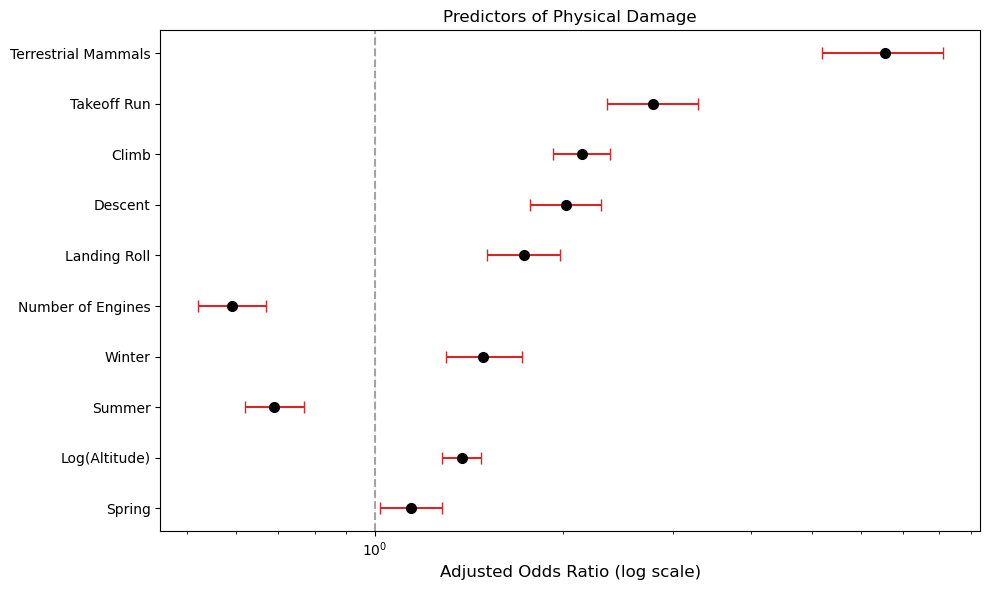

In [47]:
# Build DataFrame
df_forest = pd.DataFrame({
    "Factor": [
        'Terrestrial Mammals', 'Log(Altitude)', 'Takeoff Run', 'Climb', 'Descent',
        'Landing Roll', 'Winter', 'Spring', 'Summer', 'Number of Engines'
    ],
    "OR": np.array([6.55, 1.38, 2.78, 2.14, 2.02, 1.73, 1.49, 1.14, 0.69, 0.59]),
    "CI_L": np.array([5.20, 1.28, 2.35, 1.93, 1.77, 1.51, 1.30, 1.02, 0.62, 0.52]),
    "CI_U": np.array([8.10, 1.48, 3.29, 2.38, 2.30, 1.98, 1.72, 1.28, 0.77, 0.67])
})

# Compute effect size
df_forest["Effect"] = np.abs(np.log(df_forest["OR"]))

# Sort descending
df_forest = df_forest.sort_values("Effect", ascending=False).reset_index(drop=True)

# REVERSE ORDER for plotting (most important at top)
factors = df_forest["Factor"][::-1]
odds_ratios = df_forest["OR"][::-1]
lower_ci = df_forest["CI_L"][::-1]
upper_ci = df_forest["CI_U"][::-1]

# Compute CI errors
error_lower = odds_ratios - lower_ci
error_upper = upper_ci - odds_ratios

plt.figure(figsize=(10, 6))

plt.errorbar(
    odds_ratios, factors,
    xerr=[error_lower, error_upper],
    fmt='o',
    color='black',
    markersize=7,
    ecolor='#d62728',
    capsize=4
)

plt.axvline(1, linestyle='--', color='gray', alpha=0.7)
plt.xscale('log')

plt.xlabel('Adjusted Odds Ratio (log scale)', fontsize=12)
plt.title('Predictors of Physical Damage',
          fontsize=12, fontweight='normal')

plt.grid(axis='x', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

In [48]:
# Predictions & residuals
df_model["pred_prob"] = glm_model.predict(df_model)
df_model["resid_deviance"] = glm_model.resid_deviance
df_model["resid_pearson"] = glm_model.resid_pearson
df_model["resid_working"] = glm_model.resid_working

In [49]:
df_model["pred_prob"].isna().sum()
df_model[df_model["pred_prob"].isna()].head()

,aircraft_type,aircraft_number_of_engines,collision_date_and_time,when_time_of_day,when_phase_of_flight,effect_indicated_damage,feet_above_ground,wildlife_animal_category,month,Log_Altitude,damage_flag,miles_missing,season,pred_prob,resid_deviance,resid_pearson,resid_working
0,Unknown,NaN,2012-09-20 19:30:00,Unknown,Take-off run,No damage,0.0,Terrestrial Mammals,9,0.0,0,1,Fall,NaN,NaN,NaN,NaN
1,Airplane,1.0,2013-04-23 17:09:00,Unknown,Take-off run,No damage,NaN,Birds,4,NaN,0,1,Spring,NaN,NaN,NaN,NaN
3,Airplane,2.0,2014-04-13 22:00:00,Night,Approach,No damage,NaN,Birds,4,NaN,0,1,Spring,NaN,NaN,NaN,NaN
4,Airplane,2.0,2009-03-31 18:15:00,Day,Approach,Caused damage,NaN,Birds,3,NaN,1,0,Spring,NaN,NaN,NaN,NaN
7,Airplane,NaN,2002-08-26 13:05:00,Day,Landing Roll,No damage,0.0,Birds,8,0.0,0,0,Summer,NaN,NaN,NaN,NaN


In [50]:
df_roc = df_model.dropna(subset=["pred_prob"])
df_roc.shape

(22999, 17)

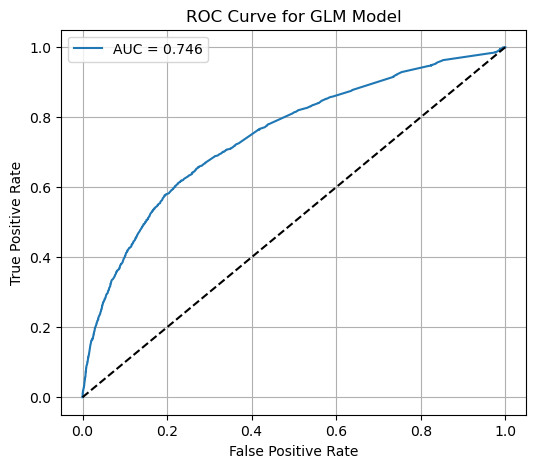

In [51]:

fpr, tpr, _ = roc_curve(df_roc["damage_flag"], df_roc["pred_prob"])
auc = roc_auc_score(df_roc["damage_flag"], df_roc["pred_prob"])

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for GLM Model")
plt.legend()
plt.grid(True)
plt.show()

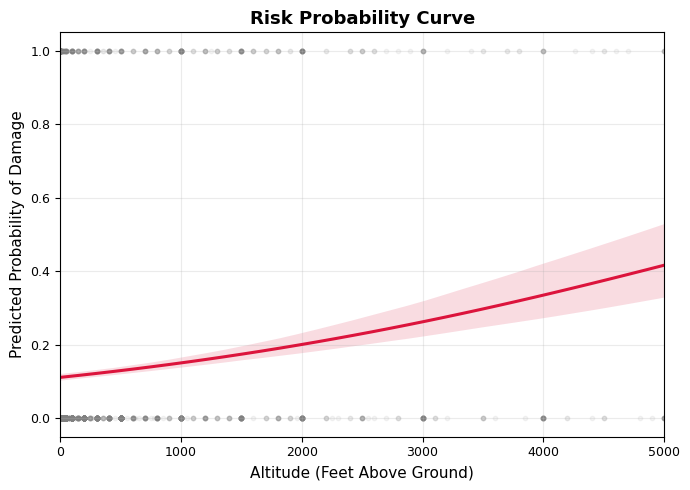

In [52]:
plt.figure(figsize=(7, 5)) 

# Subsample to reduce overplotting
sample_df = df1.sample(5000, random_state=42) if len(df1) > 5000 else df1

sns.regplot(
    data=sample_df,
    x='feet_above_ground',
    y='damage_flag',
    logistic=True,
    scatter_kws={'alpha': 0.08, 's': 10, 'color': 'gray'},
    line_kws={'color': 'crimson', 'lw': 2.2}
)

plt.title('Risk Probability Curve', fontsize=13, fontweight='bold')
plt.xlabel('Altitude (Feet Above Ground)', fontsize=11)
plt.ylabel('Predicted Probability of Damage', fontsize=11)

plt.xlim(0, 5000)

# Tick label sizes
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

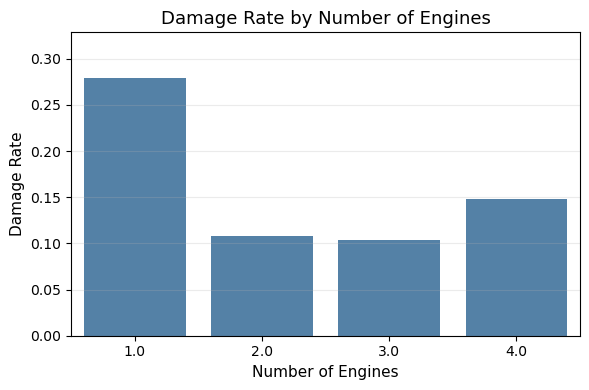

In [53]:
eng_rate = df1.groupby('aircraft_number_of_engines')['damage_flag'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=eng_rate, x='aircraft_number_of_engines', y='damage_flag', color='steelblue')

plt.xlabel('Number of Engines', fontsize=11)
plt.ylabel('Damage Rate', fontsize=11)
plt.title('Damage Rate by Number of Engines', fontsize=13)
plt.ylim(0, eng_rate['damage_flag'].max() + 0.05)

plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

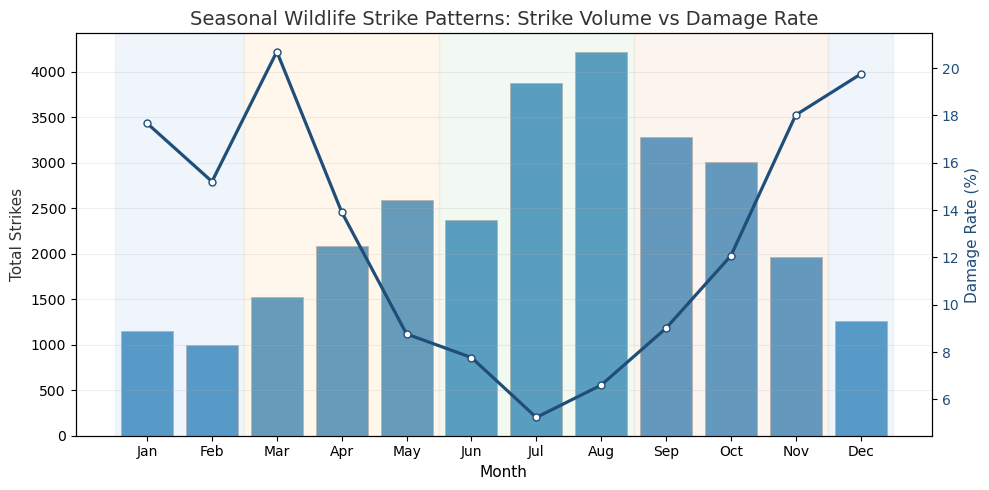

In [54]:
df1['Month'] = pd.to_datetime(df1['collision_date_and_time']).dt.month

# Monthly Aggregation
seasonal_data = df1.groupby('Month').agg(
    total_strikes=('Month', 'count'),
    damage_rate=('damage_flag', 'mean')
).reset_index()

seasonal_data['damage_rate'] *= 100
months = seasonal_data['Month']

# Figure
fig, ax1 = plt.subplots(figsize=(10, 5))

# Volume Bars (Soft Grey)
ax1.bar(
    months,
    seasonal_data['total_strikes'],
       
    edgecolor='#9c9c9c', 
    linewidth=0.6,
    label='Total Strikes'
)
ax1.set_ylabel('Total Strikes', fontsize=11, color='#333333')
ax1.set_xlabel('Month', fontsize=11)

# Damage Rate Line (Clean Navy Blue)
ax2 = ax1.twinx()
ax2.plot(
    months,
    seasonal_data['damage_rate'],
    color='#1f4e79',   
    linewidth=2.3,
    marker='o',
    markersize=5,
    markerfacecolor='white',
    markeredgecolor='#1f4e79',
    label='Damage Rate (%)'
)

ax2.set_ylabel('Damage Rate (%)', fontsize=11, color='#1f4e79')
ax2.tick_params(axis='y', labelcolor='#1f4e79')

# Season Shading
# Winter = Dec + Jan + Feb
ax1.axvspan(11.5, 12.5, color='#d0e2f2', alpha=0.32)  # December
ax1.axvspan(0.5,  2.5,  color='#d0e2f2', alpha=0.32)  # Jan–Feb

# Spring = Mar–May
ax1.axvspan(2.5, 5.5,  color='#ffe9c6', alpha=0.32)

# Summer = Jun–Aug
ax1.axvspan(5.5, 8.5,  color='#d4eed8', alpha=0.32)

# Fall = Sep–Nov
ax1.axvspan(8.5, 11.5, color='#f6dfcd', alpha=0.32)
plt.title(
    'Seasonal Wildlife Strike Patterns: Strike Volume vs Damage Rate',
    fontsize=14,
    fontweight='normal',
    color='#333333'
)

plt.xticks(
    ticks=range(1, 13),
    labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    fontsize=10
)

ax1.tick_params(axis='y', labelsize=10)
ax2.tick_params(axis='y', labelsize=10)

ax1.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

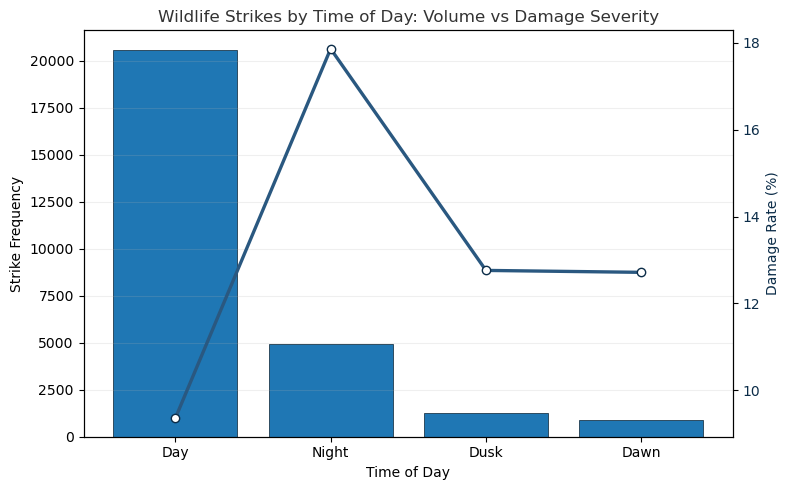

In [55]:
# --- Order categories by strike frequency ---
time_order = df["when_time_of_day"].dropna().value_counts().index

# --- Create damage flag ---
tmp = df.copy()
tmp["damage_flag"] = (tmp["effect_indicated_damage"] == "Caused damage").astype(int)

# --- Compute damage rate (%) ---
damage_by_time = (
    tmp.groupby("when_time_of_day")["damage_flag"]
       .mean()
       .loc[time_order] * 100
)

strike_counts = df["when_time_of_day"].value_counts().loc[time_order]

# --- Dual-Axis Plot ---
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bars: Strike Frequency (Standard Blue)
ax1.bar(
    time_order,
    strike_counts,
    edgecolor="#081f30",
    linewidth=0.5
)
ax1.set_ylabel("Strike Frequency", fontsize=10)
ax1.set_xlabel("Time of Day", fontsize=10)

# Line: Damage Rate (Darker Navy for contrast)
ax2 = ax1.twinx()
ax2.plot(
    time_order,
    damage_by_time.values,
    color="#2a5880", 
    linewidth=2.4,
    marker="o",
    markersize=6,
    markerfacecolor="white",
    markeredgecolor="#0b2c48"
)
ax2.set_ylabel("Damage Rate (%)", fontsize=10, color="#0b2c48")
ax2.tick_params(axis="y", labelcolor="#0b2c48")
# Formatting
plt.title("Wildlife Strikes by Time of Day: Volume vs Damage Severity",
          fontsize=12, fontweight="normal", color="#333333")

plt.xticks(rotation=25, fontsize=10)
ax1.tick_params(axis="y", labelsize=10)
ax2.tick_params(axis="y", labelsize=10)

# Light grid on left axis
ax1.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

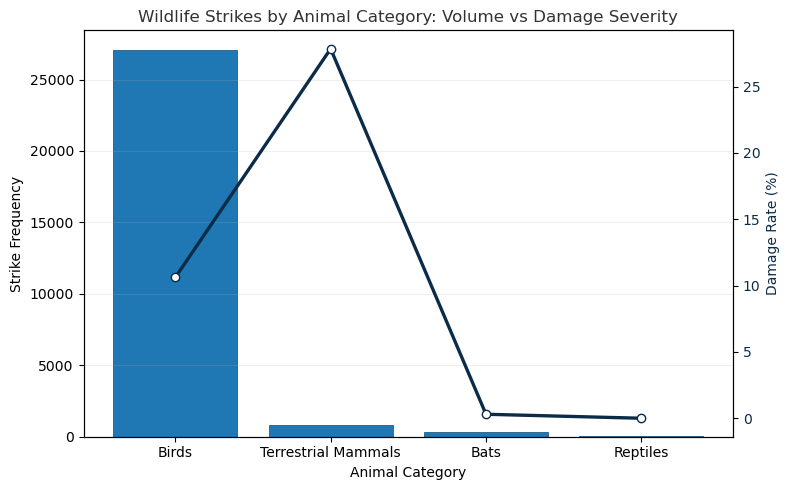

In [ ]:
tmp = df.copy()
tmp["damage_flag"] = (tmp["effect_indicated_damage"] == "Caused damage").astype(int)

#  Order categories by strike frequency 
cat_order = df["wildlife_animal_category"].value_counts().index

# Compute damage rate (%) in same order
cat_damage_rate = (
    tmp.groupby("wildlife_animal_category")["damage_flag"]
       .mean()
       .reindex(cat_order) * 100
)

strike_counts = df["wildlife_animal_category"].value_counts().reindex(cat_order)

# Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bars: Strike Frequency (Standard Blue)
ax1.bar(
    cat_order,
    strike_counts,
    color="#1f77b4",
    edgecolor="#0f4a73",
    linewidth=0.5
)
ax1.set_ylabel("Strike Frequency", fontsize=10)
ax1.set_xlabel("Animal Category", fontsize=10)

# Line: Damage Rate
ax2 = ax1.twinx()
ax2.plot(
    cat_order,
    cat_damage_rate.values,
    color="#0b2c48",
    linewidth=2.4,
    marker="o",
    markersize=6,
    markerfacecolor="white",
    markeredgecolor="#0b2c48"
)
ax2.set_ylabel("Damage Rate (%)", fontsize=10, color="#0b2c48")
ax2.tick_params(axis="y", labelcolor="#0b2c48")

# Title
plt.title(
    "Wildlife Strikes by Animal Category: Volume vs Damage Severity",
    fontsize=12,
    fontweight="normal",
    color="#333333"
)

# X-axis formatting
plt.xticks(rotation=30, ha="right", fontsize=10)
ax1.tick_params(axis="y", labelsize=10)
ax2.tick_params(axis="y", labelsize=10)

# Light grid
ax1.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()